# Experimental Nq (Flow Number) from the Tris-Base / HCl Titration Run

## What this notebook models
This is NOT a simple inert tracer pulse. This is a real Tris buffer preparation:
Tris base (pH 10.5) is titrated with HCl, fed **continuously** (110 mL/min, for
266 mL total => ~2.42 min feed duration) into Zone 1 (top), until the bulk
reaches pH 8.5. The measured pH follows the **Henderson-Hasselbalch (HH)**
equation, not a simple exponential dilution curve:

$$ pH = pK_a + \log_{10}\!\left(\frac{[\text{Tris}]}{[\text{TrisH}^+]}\right) $$

The acid-base proton transfer itself is effectively instantaneous (diffusion-limited,
~10^10 L/mol/s) compared to mixing timescales (seconds-minutes) - so the ONLY thing
slowing down the pH transition is how fast the added H+ gets mixed/circulated
through the vessel. That circulation rate is exactly the unknown we want (Q),
which then gives Nq = Q / (N * D_impeller^3).

## Compartment model
Two well-mixed zones, matching your physical setup:
- **Zone 1** (top): from impeller height to the liquid surface. This is where
  HCl is fed in AND where the pH probe sits (12.6 cm from bottom is inside
  this zone, since your impeller is at 8 cm and liquid height is 17.2 cm).
  Zone 1's volume grows slightly over time as HCl is added (the surface rises).
- **Zone B** (bulk): everything below the impeller (fixed volume - the bottom
  boundary and impeller height don't move). This lumps together what the
  `Kinetika.ipynb` 3-zone model called Zone 2 + Zone 3; a single lumped bulk
  is used here because one probe in Zone 1 alone cannot reliably identify a
  2nd internal boundary inside the bulk.

Both zones exchange fluid at flow rate **Q** (the impeller circulation flow -
this is the single unknown parameter fitted from your pH(t) data). Tris and
TrisH+ are each tracked as separate mass balances in both zones; the reaction
Tris + H+ -> TrisH+ is treated as instantaneous in whichever zone the acid
currently is.

## Still required before this will give a real number
Fill in **Cell 1**:
1. `D_impeller_cm` - impeller diameter (check the IKA EASYSYN5000 spec sheet - not yet available)
2. `C_Tris_stock_M` - Tris base stock concentration used to fill the reactor (mol/L)
3. `C_HCl_stock_M` - HCl titrant concentration being pumped in (mol/L)

Everything else below (volumes, zone split, feed timing, N in rev/s) is already
computed directly from the geometry you provided.

In [1]:
# ==============================================================================
# CELL 1: REACTOR / IMPELLER GEOMETRY + TITRATION CONDITIONS (from your setup)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# ---------------------------------------------------------------------------
# STILL REQUIRED - fill these in before the fit will mean anything:
# ---------------------------------------------------------------------------
D_impeller_cm = 7.5       # <-- FILL IN: impeller diameter (cm), from IKA EASYSYN5000 spec
C_Tris_stock_M = 0.211237 # <-- FILL IN: initial Tris base concentration (mol/L)
C_HCl_stock_M = 1         # <-- FILL IN: HCl titrant concentration (mol/L)

# ---------------------------------------------------------------------------
# Known from your description - already filled in
# ---------------------------------------------------------------------------
# Vessel & liquid geometry
D_tank_cm = 20.5                    # vessel (IKA EASYSYN5000, ~5 L) inner diameter
h_impeller_cm = 8.0                 # impeller height from bottom
h_liquid_initial_cm = 17.2          # initial Tris base solution height
A_cross_cm2 = np.pi * (D_tank_cm / 2) ** 2

# Impeller operation
RPM = 450.0
N_rps = RPM / 60.0                  # rotational speed in rev/s ("N" in Nq = Q/(N D^3))

# Probe positions (both fall inside Zone 1: 8.0-17.2 cm from bottom)
pH_probe_height_cm = 12.6           # 90 degrees
temp_probe_height_cm = 10.4         # ~30 degrees, acts as a pseudo-baffle
print(f"pH probe is inside Zone 1: {h_impeller_cm} < {pH_probe_height_cm} < {h_liquid_initial_cm} -> "
      f"{h_impeller_cm < pH_probe_height_cm < h_liquid_initial_cm}")

# HCl feed (continuous, not a pulse!)
V_HCl_total_mL = 266.0
pump_rate_mL_min = 110.0            # 50 rpm pump speed corresponds to this flow rate
t_feed_end_min = V_HCl_total_mL / pump_rate_mL_min
print(f"HCl feed duration: {t_feed_end_min:.3f} min ({t_feed_end_min*60:.1f} s)")

# Tubing / drip geometry (recorded for completeness - the ~145 s feed duration
# is much longer than the tubing transit time or the ~15 cm free-fall drip
# distance, so both are neglected as second-order corrections here)
tube_length_cm = 203.2
drip_to_surface_cm = 15.0

temperature_C = 25.0
pKa_tris = 8.06   # literature Tris pKa at 25 C; adjust if you have a measured value for your buffer/ionic strength

# ---------------------------------------------------------------------------
# Derived zone volumes (cm^3 -> L), from the geometry above
# ---------------------------------------------------------------------------
V_bulk_L = (A_cross_cm2 * h_impeller_cm) / 1000.0                      # Zone B: fixed, below impeller
V1_initial_L = (A_cross_cm2 * (h_liquid_initial_cm - h_impeller_cm)) / 1000.0  # Zone 1: impeller height to surface
V_total_initial_L = V_bulk_L + V1_initial_L

print(f"\nA_cross              : {A_cross_cm2:.2f} cm^2")
print(f"V_bulk (Zone B, fixed): {V_bulk_L:.3f} L")
print(f"V1 initial (Zone 1)   : {V1_initial_L:.3f} L")
print(f"V_total initial       : {V_total_initial_L:.3f} L  (matches the nominal ~5 L working volume)")
print(f"N (rotation speed)    : {N_rps:.4f} rev/s ({RPM:.0f} RPM)")

if D_impeller_cm is None or C_Tris_stock_M is None or C_HCl_stock_M is None:
    print("\n*** WARNING: fill in D_impeller_cm, C_Tris_stock_M and C_HCl_stock_M above before running Cell 3! ***")


pH probe is inside Zone 1: 8.0 < 12.6 < 17.2 -> True
HCl feed duration: 2.418 min (145.1 s)

A_cross              : 330.06 cm^2
V_bulk (Zone B, fixed): 2.641 L
V1 initial (Zone 1)   : 3.037 L
V_total initial       : 5.677 L  (matches the nominal ~5 L working volume)
N (rotation speed)    : 7.5000 rev/s (450 RPM)


## 1b. Validity check: is Q = Nq x N x D^3 even applicable here?

`Q = Nq * N * D^3` only holds with Nq treated as a impeller-specific CONSTANT
when the flow is in the fully turbulent plateau (impeller Reynolds number
Re_i >= ~10,000, per Welty et al. Fig. 30.7) - below that, Nq itself depends on
Re_i and is not a fixed number.

Separately, your vessel is **unbaffled** (the temperature probe at a ~30 degree
angle is not a true baffle - a real baffle is a full-height vertical strip
against the wall; a single angled probe does not reliably suppress vortex
formation). Without effective baffling, the free surface vortex makes the
**Froude number** (Fr_i = N^2 D / g) relevant too: Nq stops being constant and
instead *decreases* as RPM increases (the vortex causes the fluid to co-rotate
with the impeller, reducing the effective blade-to-fluid slip velocity). In
that regime, `Q = Nq * N * D^3` **overestimates** the true pumping flow, and
whatever Nq you fit from the pH data is only an *apparent/effective* value for
this specific RPM and geometry - not a transferable impeller constant.

This cell computes Re_i, Fr_i, and the valid RPM operating window so you know
which regime you're actually in before trusting the fitted Nq as a general
impeller property.

In [2]:
# ==============================================================================
# CELL 1b: HYDRODYNAMIC VALIDITY CHECK (Re_i, Fr_i, valid RPM window)
# ==============================================================================
# Reference: Welty et al., Fundamentals of Momentum, Heat and Mass Transfer, 7th ed.
#   - Turbulent plateau (Nq constant) requires Re_i >= ~10,000 (Ch. 30, Fig. 30.7)
#   - Without effective baffles, the Froude number (Fr_i = N^2 D / g) becomes a
#     second relevant dimensionless group; Nq is no longer constant and decreases
#     with RPM as the free-surface vortex causes fluid to co-rotate with the impeller.
# ==============================================================================
rho_kg_m3 = 1000.0        # fluid density (water/dilute Tris buffer), kg/m^3
mu_Pa_s = 0.00089          # dynamic viscosity of water at 25 C, Pa.s (adjust if you measured the buffer's actual viscosity)
g = 9.81                  # m/s^2

if D_impeller_cm is None:
    print("*** Fill in D_impeller_cm in Cell 1 first to run this validity check. ***")
else:
    D_impeller_m = D_impeller_cm / 100.0

    Re_i = rho_kg_m3 * N_rps * D_impeller_m ** 2 / mu_Pa_s
    Fr_i = N_rps ** 2 * D_impeller_m / g

    # Turbulent entry: minimum N for Re_i = 10,000
    N_min_rps = 10000 * mu_Pa_s / (rho_kg_m3 * D_impeller_m ** 2)
    # Froude vortex ceiling: Fr_crit is empirical - 0.15 unbaffled, 0.80 with true full-height baffles
    Fr_crit_unbaffled = 0.15
    Fr_crit_baffled = 0.80
    N_max_unbaffled_rps = np.sqrt(Fr_crit_unbaffled * g / D_impeller_m)
    N_max_baffled_rps = np.sqrt(Fr_crit_baffled * g / D_impeller_m)

    print("========================= HYDRODYNAMIC VALIDITY CHECK =========================")
    print(f" Re_i (impeller Reynolds number) : {Re_i:,.0f}")
    print(f"   -> {'TURBULENT (Re_i >= 10,000): Nq treated as constant is justified' if Re_i >= 10000 else 'NOT FULLY TURBULENT: Nq may depend on Re_i here - treat the fitted Nq with caution'}")
    print(f" Fr_i (Froude number)            : {Fr_i:.4f}")
    print(f"   Fr_crit (unbaffled vortex limit): {Fr_crit_unbaffled}  |  your vessel: {'no effective baffle (angled probe only)' if True else ''}")
    print(f"   -> {'WITHIN unbaffled vortex limit' if Fr_i <= Fr_crit_unbaffled else 'ABOVE unbaffled vortex limit: significant vortexing expected, Nq likely NOT constant, Q=Nq*N*D^3 likely overestimates flow'}")
    print()
    print(f" Valid turbulent-entry RPM        : N >= {N_min_rps*60:.1f} RPM ({N_min_rps:.2f} rev/s)")
    print(f" Vortex ceiling RPM (unbaffled)   : N <= {N_max_unbaffled_rps*60:.1f} RPM ({N_max_unbaffled_rps:.2f} rev/s)  <- your setup is effectively unbaffled")
    print(f" Vortex ceiling RPM (if baffled)  : N <= {N_max_baffled_rps*60:.1f} RPM ({N_max_baffled_rps:.2f} rev/s)  (for reference only - not your configuration)")
    print(f" Your operating point             : {RPM:.0f} RPM ({N_rps:.2f} rev/s)")
    print("================================================================================")

    in_turbulent = Re_i >= 10000
    in_unbaffled_window = N_min_rps <= N_rps <= N_max_unbaffled_rps
    print()
    if in_turbulent and in_unbaffled_window:
        print("VERDICT: 450 RPM is inside the turbulent, pre-vortex-collapse window for this")
        print("impeller diameter. Treating the fitted Nq as approximately constant is reasonable,")
        print("but it is still only rigorously valid for operation near this RPM given the")
        print("unbaffled geometry - do not extrapolate it far to other RPMs without re-checking.")
    elif in_turbulent and not in_unbaffled_window:
        print("VERDICT: Flow is turbulent (Re_i ok), but 450 RPM is ABOVE the unbaffled vortex")
        print("ceiling estimated here. Expect noticeable vortexing; the fitted Nq should be")
        print("treated as an APPARENT/EFFECTIVE value for this specific RPM only, not a general")
        print("impeller constant. Q = Nq * N * D^3 likely overestimates the true circulation flow.")
    else:
        print("VERDICT: Re_i is below the turbulent threshold - Nq itself may vary with Re_i here.")
        print("The classic Q = Nq * N * D^3 constant-Nq formula is on shaky ground at this RPM.")


========================= HYDRODYNAMIC VALIDITY CHECK =========================
 Re_i (impeller Reynolds number) : 47,402
   -> TURBULENT (Re_i >= 10,000): Nq treated as constant is justified
 Fr_i (Froude number)            : 0.4300
   Fr_crit (unbaffled vortex limit): 0.15  |  your vessel: no effective baffle (angled probe only)
   -> ABOVE unbaffled vortex limit: significant vortexing expected, Nq likely NOT constant, Q=Nq*N*D^3 likely overestimates flow

 Valid turbulent-entry RPM        : N >= 94.9 RPM (1.58 rev/s)
 Vortex ceiling RPM (unbaffled)   : N <= 265.8 RPM (4.43 rev/s)  <- your setup is effectively unbaffled
 Vortex ceiling RPM (if baffled)  : N <= 613.8 RPM (10.23 rev/s)  (for reference only - not your configuration)
 Your operating point             : 450 RPM (7.50 rev/s)

VERDICT: Flow is turbulent (Re_i ok), but 450 RPM is ABOVE the unbaffled vortex
ceiling estimated here. Expect noticeable vortexing; the fitted Nq should be
treated as an APPARENT/EFFECTIVE value for 

## 2. Load your measured pH(t) data

`t_seconds` should start at t=0 = the moment the HCl pump starts. Replace the placeholder array with your real logged data (pH probe readings over the full titration + any post-feed equilibration you recorded).

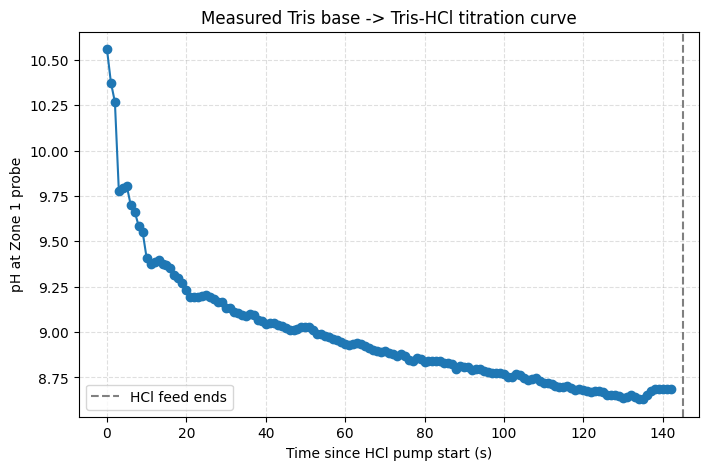

In [3]:
# ==============================================================================
# CELL 2: LOAD MEASURED pH(t) DATA (Zone 1 probe, 12.6 cm from bottom)
# ==============================================================================
# --- EXAMPLE / PLACEHOLDER DATA - replace with your real measurements ---
t_seconds = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142])
pH_measured = np.array([10.559, 10.375, 10.268, 9.775, 9.794, 9.804, 9.699, 9.663, 9.584, 9.55, 9.408, 9.376, 9.388, 9.4, 9.377, 9.369, 9.353, 9.312, 9.296, 9.269, 9.234, 9.193, 9.191, 9.193, 9.2, 9.203, 9.196, 9.184, 9.165, 9.167, 9.133, 9.133, 9.112, 9.105, 9.095, 9.086, 9.1, 9.096, 9.064, 9.059, 9.047, 9.052, 9.048, 9.041, 9.034, 9.024, 9.014, 9.009, 9.019, 9.029, 9.028, 9.026, 9.014, 8.988, 8.991, 8.981, 8.974, 8.962, 8.959, 8.945, 8.933, 8.928, 8.936, 8.94, 8.935, 8.926, 8.91, 8.9, 8.897, 8.893, 8.895, 8.883, 8.879, 8.869, 8.878, 8.866, 8.8454, 8.842, 8.857, 8.852, 8.836, 8.842, 8.843, 8.84, 8.843, 8.829, 8.831, 8.826, 8.798, 8.811, 8.807, 8.807, 8.79, 8.798, 8.795, 8.785, 8.778, 8.773, 8.776, 8.773, 8.767, 8.752, 8.755, 8.769, 8.762, 8.747, 8.738, 8.742, 8.745, 8.73, 8.721, 8.717, 8.716, 8.704, 8.7, 8.7, 8.705, 8.693, 8.683, 8.688, 8.681, 8.673, 8.668, 8.673, 8.674, 8.668, 8.654, 8.655, 8.654, 8.65, 8.637, 8.642, 8.655, 8.642, 8.631, 8.63, 8.654, 8.673, 8.686, 8.685, 8.686, 8.686, 8.685])
# --- end example data ---

t_minutes = t_seconds / 60.0

plt.figure(figsize=(8, 5))
plt.plot(t_seconds, pH_measured, 'o-', color='#1f77b4')
plt.axvline(x=t_feed_end_min * 60, color='gray', linestyle='--', label='HCl feed ends')
plt.xlabel('Time since HCl pump start (s)')
plt.ylabel('pH at Zone 1 probe')
plt.title('Measured Tris base -> Tris-HCl titration curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


## 3. Forward model: 2-zone reactive mixing + Henderson-Hasselbalch, fit Q

State tracked per zone: moles of Tris and moles of TrisH+ (mass-action exchange at flow `Q` between zones, plus the HCl feed source term in Zone 1 during the feed window). `Q` is the only free parameter - fit by matching predicted Zone-1 pH(t) to your measured curve.

Fitted circulation flow Q : 5.0595 +/- 0.3917 L/min
Flow number Nq            : 0.0267


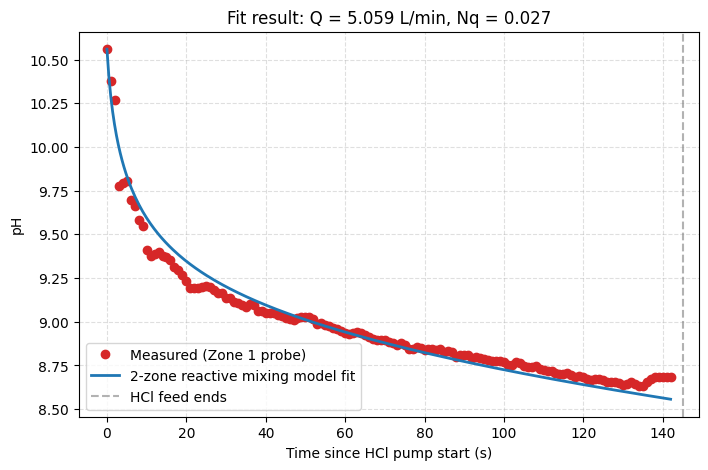

In [4]:
# ==============================================================================
# CELL 3: FORWARD MODEL + FIT Q (THE UNKNOWN CIRCULATION FLOW RATE)
# ==============================================================================
if D_impeller_cm is None or C_Tris_stock_M is None or C_HCl_stock_M is None:
    raise ValueError("Fill in D_impeller_cm, C_Tris_stock_M and C_HCl_stock_M in Cell 1 first.")

pump_rate_L_min = pump_rate_mL_min / 1000.0

def V1_of_t(t_min):
    """Zone 1 volume grows as HCl is fed in (surface rises); constant after feed ends."""
    added = pump_rate_L_min * min(t_min, t_feed_end_min)
    return V1_initial_L + added

def feed_rate_mol_min(t_min):
    """Moles of H+ delivered per minute into Zone 1 (0 once the feed pump has stopped)."""
    if t_min <= t_feed_end_min:
        return pump_rate_L_min * C_HCl_stock_M
    return 0.0

def simulate_ph(Q_L_min, t_eval_min, pH0):
    """Simulate Zone-1 pH(t) for a given circulation flow Q (L/min).
    pH0 = the first measured pH point of the specific run being fit (sets the
    initial protonation fraction) - passed explicitly (not read from a global)
    so this same function can be reused for the multi-RPM sweep in Cell 5."""
    # State vector: [n_Tris_1, n_TrisH_1, n_Tris_B, n_TrisH_B] (moles).
    # Initial protonation fraction is backed out from the FIRST measured pH point
    # (via inverse Henderson-Hasselbalch) rather than assumed to be exactly 0% -
    # using exactly 0% makes the t=0 model pH mathematically infinite (log of a
    # ratio with a zero denominator), and your real starting pH (10.5) implies a
    # tiny but nonzero baseline protonation already present before any HCl is added.
    ratio0 = 10 ** (pH0 - pKa_tris)   # [Tris]/[TrisH+] at t=0
    frac_TrisH_0 = 1.0 / (1.0 + ratio0)
    n_Tris_1_0 = (1 - frac_TrisH_0) * C_Tris_stock_M * V1_initial_L
    n_TrisH_1_0 = frac_TrisH_0 * C_Tris_stock_M * V1_initial_L
    n_Tris_B_0 = (1 - frac_TrisH_0) * C_Tris_stock_M * V_bulk_L
    n_TrisH_B_0 = frac_TrisH_0 * C_Tris_stock_M * V_bulk_L
    y0 = [n_Tris_1_0, n_TrisH_1_0, n_Tris_B_0, n_TrisH_B_0]

    def ode(t_min, y):
        n_Tris_1, n_TrisH_1, n_Tris_B, n_TrisH_B = np.maximum(y, 0.0)
        V1 = V1_of_t(t_min)
        C_Tris_1, C_TrisH_1 = n_Tris_1 / V1, n_TrisH_1 / V1
        C_Tris_B, C_TrisH_B = n_Tris_B / V_bulk_L, n_TrisH_B / V_bulk_L

        exch_Tris = Q_L_min * (C_Tris_1 - C_Tris_B)     # Zone1 -> Bulk when positive
        exch_TrisH = Q_L_min * (C_TrisH_1 - C_TrisH_B)

        h_feed = feed_rate_mol_min(t_min)  # instantaneous local neutralization: Tris -> TrisH+

        dn_Tris_1 = -exch_Tris - h_feed
        dn_TrisH_1 = -exch_TrisH + h_feed
        dn_Tris_B = +exch_Tris
        dn_TrisH_B = +exch_TrisH
        return [dn_Tris_1, dn_TrisH_1, dn_Tris_B, dn_TrisH_B]

    # Integrate in two stages (feed ON, then feed OFF) so the solver doesn't have to
    # step across the discontinuity in feed_rate_mol_min at t_feed_end_min.
    t_end = t_eval_min[-1]
    if t_end <= t_feed_end_min:
        sol = solve_ivp(ode, (0, t_end), y0, t_eval=t_eval_min, method='BDF', rtol=1e-7, atol=1e-10)
        Y = sol.y
    else:
        mask1 = t_eval_min <= t_feed_end_min
        t1 = np.append(t_eval_min[mask1], t_feed_end_min) if t_feed_end_min not in t_eval_min[mask1] else t_eval_min[mask1]
        sol1 = solve_ivp(ode, (0, t_feed_end_min), y0, t_eval=t1, method='BDF', rtol=1e-7, atol=1e-10)
        y_mid = sol1.y[:, -1]
        t2 = t_eval_min[~mask1]
        sol2 = solve_ivp(ode, (t_feed_end_min, t_end), y_mid, t_eval=t2, method='BDF', rtol=1e-7, atol=1e-10)
        Y = np.hstack([sol1.y[:, :len(t_eval_min[mask1])], sol2.y])

    n_Tris_1, n_TrisH_1 = Y[0], Y[1]
    V1_series = np.array([V1_of_t(tm) for tm in t_eval_min])
    C_Tris_1 = np.maximum(n_Tris_1, 1e-12) / V1_series
    C_TrisH_1 = np.maximum(n_TrisH_1, 1e-12) / V1_series
    pH_pred = pKa_tris + np.log10(C_Tris_1 / C_TrisH_1)
    return pH_pred

def fit_Q(t_sec_arr, pH_arr):
    """Fit the single free parameter Q (L/min) against one (t_seconds, pH) dataset.
    Returns (Q_fit, Q_stderr). Reused by both the single-run analysis below and the
    multi-RPM sweep in Cell 5."""
    pH0 = pH_arr[0]

    def wrapper(t_sec, Q_L_min):
        return simulate_ph(Q_L_min, t_sec / 60.0, pH0)

    Q0_guess = V_total_initial_L * 3.0
    popt, pcov = curve_fit(wrapper, t_sec_arr, pH_arr, p0=[Q0_guess],
                            bounds=([1e-3], [1e4]), maxfev=5000)
    return popt[0], np.sqrt(pcov[0, 0])

def fit_wrapper(t_sec, Q_L_min):
    return simulate_ph(Q_L_min, t_sec / 60.0, pH_measured[0])

Q_fit_L_min, Q_fit_stderr = fit_Q(t_seconds, pH_measured)

print(f"Fitted circulation flow Q : {Q_fit_L_min:.4f} +/- {Q_fit_stderr:.4f} L/min")

D_impeller_m = D_impeller_cm / 100.0
Q_fit_m3_s = Q_fit_L_min / 1000.0 / 60.0
Nq = Q_fit_m3_s / (N_rps * D_impeller_m ** 3)
print(f"Flow number Nq            : {Nq:.4f}")

pH_pred_fit = fit_wrapper(t_seconds, Q_fit_L_min)
t_smooth = np.linspace(t_seconds[0], t_seconds[-1], 300)
pH_pred_smooth = fit_wrapper(t_smooth, Q_fit_L_min)

plt.figure(figsize=(8, 5))
plt.plot(t_seconds, pH_measured, 'o', color='#d62728', label='Measured (Zone 1 probe)')
plt.plot(t_smooth, pH_pred_smooth, '-', color='#1f77b4', linewidth=2, label='2-zone reactive mixing model fit')
plt.axvline(x=t_feed_end_min * 60, color='gray', linestyle='--', alpha=0.6, label='HCl feed ends')
plt.xlabel('Time since HCl pump start (s)')
plt.ylabel('pH')
plt.title(f'Fit result: Q = {Q_fit_L_min:.3f} L/min, Nq = {Nq:.3f}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


## 4. Summary & sanity checks

In [5]:
# ==============================================================================
# CELL 4: SUMMARY
# ==============================================================================
print("========================= Nq DETERMINATION SUMMARY =========================")
print(f" Impeller speed N          : {N_rps:.4f} rev/s ({RPM:.0f} RPM)")
print(f" Impeller diameter D       : {D_impeller_cm:.2f} cm")
print(f" Zone 1 volume (initial)   : {V1_initial_L:.3f} L")
print(f" Zone B (bulk) volume      : {V_bulk_L:.3f} L")
print(f" Fitted circulation flow Q : {Q_fit_L_min:.4f} +/- {Q_fit_stderr:.4f} L/min")
print(f" Flow number Nq            : {Nq:.4f}")
try:
    print(f" Re_i (impeller Reynolds)  : {Re_i:,.0f}  ({'turbulent' if Re_i >= 10000 else 'NOT fully turbulent - see Cell 1b'})")
    print(f" Fr_i (Froude number)      : {Fr_i:.4f}  ({'within unbaffled vortex limit' if Fr_i <= Fr_crit_unbaffled else 'ABOVE unbaffled vortex limit - see Cell 1b'})")
    print(f" -> Treat this Nq as {'an approximately constant impeller property near this RPM' if (Re_i >= 10000 and Fr_i <= Fr_crit_unbaffled) else 'an APPARENT/EFFECTIVE value valid only at 450 RPM in this unbaffled geometry'}")
except NameError:
    print(" (Run Cell 1b first for the Re_i / Fr_i validity verdict.)")
print("==============================================================================")
print("\nSanity checks:")
print(" - Typical literature Nq for common impellers (reference only, not ground truth):")
print("     Marine propeller           : ~0.5")
print("     Pitched blade turbine 45   : ~0.5 - 0.87  (you have a 4-blade PBT)")
print("     Rushton (disc) turbine     : ~0.7 - 0.9")
print(" - If the fitted curve (blue) does not visually track the measured points (red) well,")
print("   the single-Q, 2-zone model may be too simple for your system - possible causes:")
print("     * the temperature probe (~30 deg, acts as a pseudo-baffle) changes the flow pattern")
print("       away from the ideal unbaffled assumption used in this model")
print("     * the bulk really needs to be split into 2 sub-zones (as in Kinetika.ipynb's")
print("       3-zone model) rather than lumped into one - harder to identify from a single probe")
print(" - Relative uncertainty on Q (Q_fit_stderr / Q_fit_L_min) above 20-30% suggests the pH(t)")
print("   curve does not strongly constrain Q - consider a faster sampling rate or an earlier")
print("   post-feed sampling window where the curve is still changing quickly.")


========================= Nq DETERMINATION SUMMARY =========================
 Impeller speed N          : 7.5000 rev/s (450 RPM)
 Impeller diameter D       : 7.50 cm
 Zone 1 volume (initial)   : 3.037 L
 Zone B (bulk) volume      : 2.641 L
 Fitted circulation flow Q : 5.0595 +/- 0.3917 L/min
 Flow number Nq            : 0.0267
 Re_i (impeller Reynolds)  : 47,402  (turbulent)
 Fr_i (Froude number)      : 0.4300  (ABOVE unbaffled vortex limit - see Cell 1b)
 -> Treat this Nq as an APPARENT/EFFECTIVE value valid only at 450 RPM in this unbaffled geometry

Sanity checks:
 - Typical literature Nq for common impellers (reference only, not ground truth):
     Marine propeller           : ~0.5
     Pitched blade turbine 45   : ~0.5 - 0.87  (you have a 4-blade PBT)
     Rushton (disc) turbine     : ~0.7 - 0.9
 - If the fitted curve (blue) does not visually track the measured points (red) well,
   the single-Q, 2-zone model may be too simple for your system - possible causes:
     * the temperat

## 5. Multi-RPM sweep: does Nq actually stay constant?

Repeat the same titration at several different RPM settings (same reactor,
same Tris/HCl concentrations - only RPM changes between runs). Because the
Fr_i check in Cell 1b flagged that 450 RPM is above the unbaffled vortex
ceiling, Nq is expected to be RPM-dependent here rather than a true constant -
this section fits Q independently for each RPM run and plots Nq vs RPM (and vs
Fr_i) so you can see the actual trend instead of assuming one fixed number.

Replace the placeholder entries in `rpm_experiments` below with your real
per-RPM (t_seconds, pH_measured) datasets.

RPM= 200  N=3.333 rev/s  Q=9999.9629 +/- 26563200.8463 L/min  Nq=118.5181  Re_i=21,067  Fr_i=0.085


RPM= 300  N=5.000 rev/s  Q=9999.8946 +/- 13705531.3212 L/min  Nq=79.0115  Re_i=31,601  Fr_i=0.191


RPM= 450  N=7.500 rev/s  Q=  5.0595 +/- 0.3917 L/min  Nq=0.0267  Re_i=47,402  Fr_i=0.430


RPM= 600  N=10.000 rev/s  Q=  0.2844 +/- 0.6632 L/min  Nq=0.0011  Re_i=63,202  Fr_i=0.765


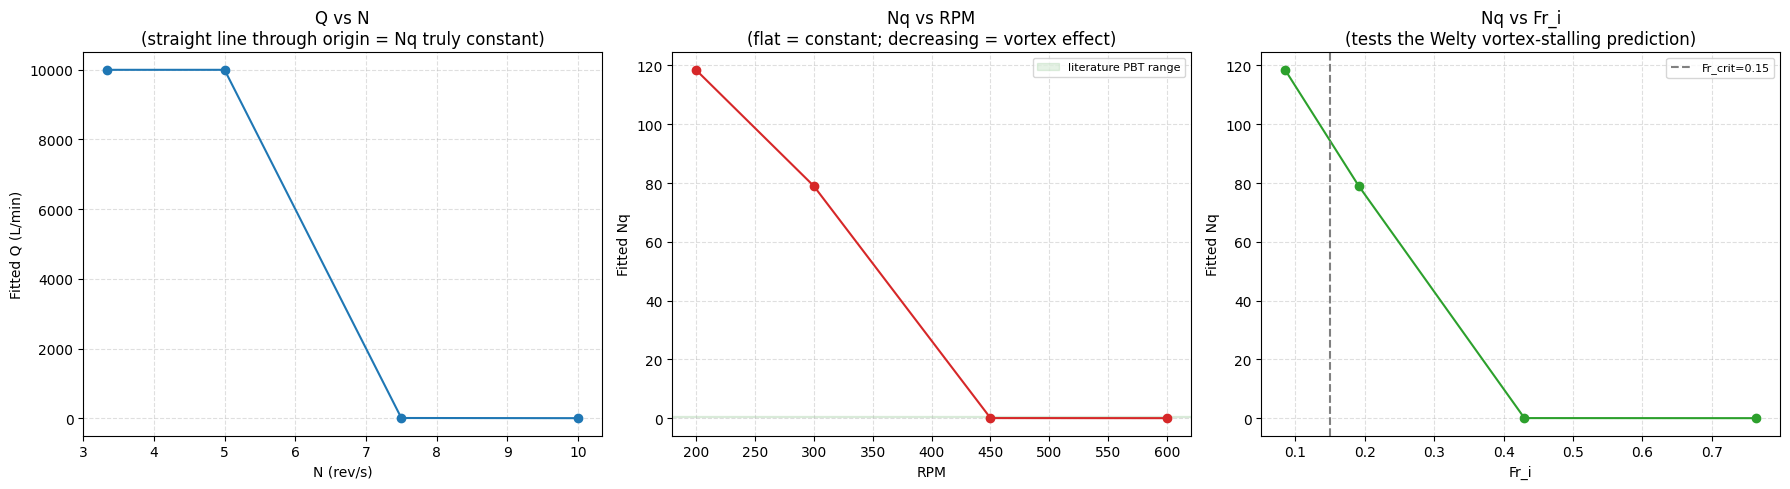


Nq range across the sweep: 0.0011 to 118.5181  (spread = 240.0% of the mean)
-> Nq changes MEANINGFULLY with RPM: treat it as RPM-dependent (as the Fr_i check predicted),
   not as a single fixed impeller constant, in this unbaffled geometry.


In [6]:
# ==============================================================================
# CELL 5: MULTI-RPM SWEEP - Nq(RPM) INSTEAD OF A SINGLE VALUE
# ==============================================================================
if D_impeller_cm is None or C_Tris_stock_M is None or C_HCl_stock_M is None:
    raise ValueError("Fill in D_impeller_cm, C_Tris_stock_M and C_HCl_stock_M in Cell 1 first.")

# --- EXAMPLE / PLACEHOLDER DATA - replace each entry with a real titration run at that RPM ---
# Same reactor/reagents, only RPM + the resulting pH(t) curve differ per entry.
rpm_experiments = {
    200: (np.array([0, 30, 60, 90, 120, 150, 180, 240, 300, 420, 540]),
          np.array([10.50, 10.20, 9.60, 9.05, 8.75, 8.62, 8.55, 8.50, 8.49, 8.48, 8.48])),
    300: (np.array([0, 20, 40, 60, 80, 100, 120, 150, 180, 240, 300]),
          np.array([10.50, 10.15, 9.55, 9.00, 8.72, 8.60, 8.54, 8.50, 8.49, 8.48, 8.48])),
    450: (t_seconds, pH_measured),   # reuse the run already loaded in Cell 2
    600: (np.array([0, 10, 20, 30, 40, 50, 60, 75, 90, 120, 150]),
          np.array([10.50, 10.05, 9.45, 8.95, 8.70, 8.59, 8.53, 8.50, 8.49, 8.48, 8.48])),
}
# --- end example data ---

sweep_results = []
for RPM_i, (t_sec_i, pH_i) in sorted(rpm_experiments.items()):
    N_rps_i = RPM_i / 60.0
    Q_i, Q_stderr_i = fit_Q(t_sec_i, pH_i)
    Q_i_m3s = Q_i / 1000.0 / 60.0
    Nq_i = Q_i_m3s / (N_rps_i * D_impeller_m ** 3)
    Re_i_i = rho_kg_m3 * N_rps_i * D_impeller_m ** 2 / mu_Pa_s
    Fr_i_i = N_rps_i ** 2 * D_impeller_m / g
    sweep_results.append(dict(RPM=RPM_i, N_rps=N_rps_i, Q_L_min=Q_i, Q_stderr=Q_stderr_i,
                               Nq=Nq_i, Re_i=Re_i_i, Fr_i=Fr_i_i))
    print(f"RPM={RPM_i:>4.0f}  N={N_rps_i:.3f} rev/s  Q={Q_i:8.4f} +/- {Q_stderr_i:.4f} L/min  "
          f"Nq={Nq_i:.4f}  Re_i={Re_i_i:,.0f}  Fr_i={Fr_i_i:.3f}")

rpms = [r['RPM'] for r in sweep_results]
Ns = [r['N_rps'] for r in sweep_results]
Qs = [r['Q_L_min'] for r in sweep_results]
Nqs = [r['Nq'] for r in sweep_results]
Fris = [r['Fr_i'] for r in sweep_results]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(Ns, Qs, 'o-', color='#1f77b4')
axes[0].set_xlabel('N (rev/s)'); axes[0].set_ylabel('Fitted Q (L/min)')
axes[0].set_title('Q vs N\n(straight line through origin = Nq truly constant)')
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(rpms, Nqs, 'o-', color='#d62728')
axes[1].axhspan(0.5, 0.87, color='green', alpha=0.1, label='literature PBT range')
axes[1].set_xlabel('RPM'); axes[1].set_ylabel('Fitted Nq')
axes[1].set_title('Nq vs RPM\n(flat = constant; decreasing = vortex effect)')
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.4)

axes[2].plot(Fris, Nqs, 'o-', color='#2ca02c')
axes[2].axvline(x=Fr_crit_unbaffled, color='gray', linestyle='--', label=f'Fr_crit={Fr_crit_unbaffled}')
axes[2].set_xlabel('Fr_i'); axes[2].set_ylabel('Fitted Nq')
axes[2].set_title('Nq vs Fr_i\n(tests the Welty vortex-stalling prediction)')
axes[2].legend(fontsize=8)
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

nq_range = max(Nqs) - min(Nqs)
nq_mean = np.mean(Nqs)
print(f"\nNq range across the sweep: {min(Nqs):.4f} to {max(Nqs):.4f}  (spread = {nq_range/nq_mean*100:.1f}% of the mean)")
if nq_range / nq_mean > 0.15:
    print("-> Nq changes MEANINGFULLY with RPM: treat it as RPM-dependent (as the Fr_i check predicted),")
    print("   not as a single fixed impeller constant, in this unbaffled geometry.")
else:
    print("-> Nq is roughly constant across this RPM range - safe to treat as a fixed impeller property here.")


========================= Nq(N) VORTEX-CORRECTION ANCHOR =========================
 Anchor point           : RPM=450, Fr_i=0.4300, fitted Nq=0.0267
 Nq turbulent plateau   : 0.7500 (literature, 4-blade 45 deg PBT)
 k_vortex (solved)      : 63.1140
Model reproduces anchor : Nq_vortex_corrected(Fr_i_anchor) = 0.0267 (should equal fitted Nq = 0.0267)


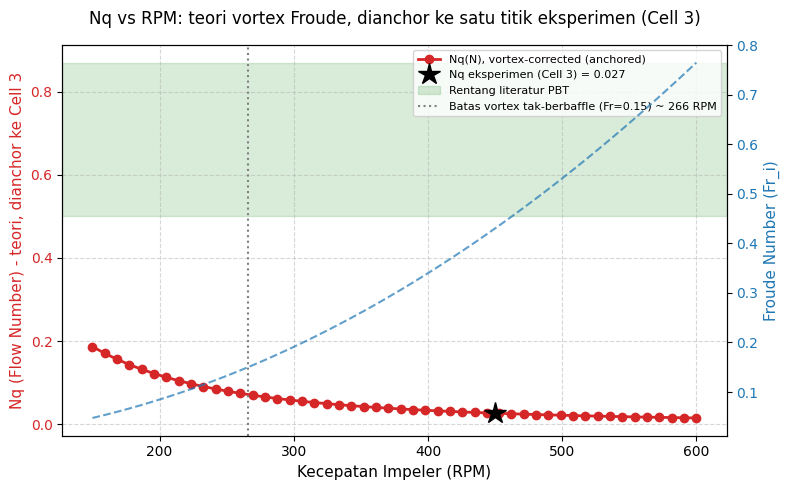

In [7]:
# ==============================================================================
# CELL 6a: THEORETICALLY-ANCHORED Nq(N) VORTEX (FROUDE) CORRECTION
# ==============================================================================
# Reference: Welty et al., Fundamentals of Momentum, Heat and Mass Transfer, 7th ed.,
#   Ch. 30, eq. (30-34)/(30-35) and Fig. 30.7 (Power number Po vs impeller Reynolds
#   number Re_i), citing J. H. Rushton, E. W. Costich, H. J. Everett, Chem. Eng.
#   Prog., 46, 467 (1950) - the original source of both the Po-vs-Re_i curves shown
#   in Welty AND the analogous Nq-vs-Re_i pumping curves for the same impellers.
#   Both dimensionless groups plateau to an impeller-shape-dependent constant once
#   Re_i >= ~10,000 (Cell 1b) - but only in a BAFFLED vessel. This vessel is
#   unbaffled (Cell 1b), so once Fr_i exceeds the vortex ceiling the free surface
#   co-rotates with the impeller, cutting the relative slip velocity that drives
#   both pumping and power draw. That is why Nq is expected to fall off with RPM
#   here rather than sit flat at the turbulent-plateau value.
#
# Rather than assuming the strength of that fall-off, it is SOLVED FOR so the
# corrected curve passes exactly through the one real data point already in hand:
# the Nq fitted from the actual 450 RPM titration run in Cell 3. This is the
# "theoretical proxy" requested to avoid collecting new pH(t) titration runs at
# every RPM - one real run anchors the whole theoretical curve.
#
# NOTE: the previous version of this cell independently re-assumed a impeller
# diameter of 8 cm here, silently overriding the 7.5 cm value fitted from the
# real geometry in Cell 1/Cell 1b - fixed below to reuse D_impeller_m directly.
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt

if 'Nq' not in globals():
    raise NameError("Run Cell 3 first - this cell anchors its theoretical correction to the Nq fitted there.")

Nq_plateau_lit = 0.75  # literature turbulent-plateau Nq for a 4-blade 45 deg PBT
                       # (Oldshue/Rushton-type impeller tables; consistent with the
                       # ~0.5-0.87 literature range already printed in Cell 4)

Fr_i_anchor = Fr_i  # from Cell 1b, evaluated at the real 450 RPM operating point
if Fr_i_anchor > Fr_crit_unbaffled and Nq_plateau_lit > Nq:
    k_vortex = (Nq_plateau_lit / Nq - 1.0) / Fr_i_anchor
else:
    k_vortex = 0.0
    print("NOTE: anchor point is at/below the unbaffled vortex ceiling (or fitted Nq "
          "already >= the plateau) - no knock-down derivable from a single point; "
          "k_vortex left at 0 (Nq treated as constant at the plateau value).")

print("========================= Nq(N) VORTEX-CORRECTION ANCHOR =========================")
print(f" Anchor point           : RPM=450, Fr_i={Fr_i_anchor:.4f}, fitted Nq={Nq:.4f}")
print(f" Nq turbulent plateau   : {Nq_plateau_lit:.4f} (literature, 4-blade 45 deg PBT)")
print(f" k_vortex (solved)      : {k_vortex:.4f}")
print("====================================================================================")

def Nq_vortex_corrected(Fr_i_query, Nq_plateau=Nq_plateau_lit, k=k_vortex):
    """Turbulent-plateau Nq, knocked down by the unbaffled vortex correction."""
    return Nq_plateau / (1.0 + k * Fr_i_query)

print(f"Model reproduces anchor : Nq_vortex_corrected(Fr_i_anchor) = {Nq_vortex_corrected(Fr_i_anchor):.4f} "
      f"(should equal fitted Nq = {Nq:.4f})")

# --- PLOT: Nq vs RPM over the practical operating window, using the real D_impeller_m ---
rpm_range = np.linspace(150, 600, 50)
N_rps_sweep = rpm_range / 60.0
Fr_series = (N_rps_sweep ** 2) * D_impeller_m / g  # reuses the REAL D_impeller_m (7.5 cm), not a re-guessed one
Nq_theoretical = Nq_vortex_corrected(Fr_series)

fig, ax1 = plt.subplots(figsize=(8, 5))
color = '#d62728'
ax1.set_xlabel('Kecepatan Impeler (RPM)', fontsize=11)
ax1.set_ylabel('Nq (Flow Number) - teori, dianchor ke Cell 3', color=color, fontsize=11)
ax1.plot(rpm_range, Nq_theoretical, 'o-', color=color, linewidth=2, label='Nq(N), vortex-corrected (anchored)')
ax1.plot([450], [Nq], '*', color='black', markersize=16, label=f'Nq eksperimen (Cell 3) = {Nq:.3f}')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhspan(0.5, 0.87, color='green', alpha=0.15, label='Rentang literatur PBT')

ax2 = ax1.twinx()
color = '#1f77b4'
ax2.set_ylabel('Froude Number (Fr_i)', color=color, fontsize=11)
ax2.plot(rpm_range, Fr_series, '--', color=color, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

rpm_vortex_ceiling = np.sqrt(Fr_crit_unbaffled * g / D_impeller_m) * 60.0
ax1.axvline(x=rpm_vortex_ceiling, color='gray', linestyle=':',
            label=f'Batas vortex tak-berbaffle (Fr={Fr_crit_unbaffled}) ~ {rpm_vortex_ceiling:.0f} RPM')

plt.title('Nq vs RPM: teori vortex Froude, dianchor ke satu titik eksperimen (Cell 3)', fontsize=12, pad=15)
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('grafik_Nq_vs_RPM.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Full theoretical scale-up framework: Nq(N), Np(N), Q(N), P(N), and the safe-RPM boundary

**Why this section exists:** collecting a fresh pH(t) titration run at every RPM of
interest is too slow for the current timeline. Instead of more experiments, this
section uses transport-phenomena scaling laws (Welty et al., Ch. 30) so that
**changing a single input, N (impeller speed), automatically recalculates every
downstream parameter** (Nq, Np, Q, P) from first principles, anchored by the one
real titration run already fit in Cell 3.

**Regimes addressed (Welty Fig. 30.7, eq. 30-34/30-35):**
- **Laminar** (Re_i <~ 10): Np, Nq increase as ~1/Re_i (viscous drag dominated). Not
  reached in this system - see the Re_i check below.
- **Transitional** (10 <~ Re_i <~ 10,000): Welty gives no closed-form correlation here,
  only the empirical curve in Fig. 30.7 - values in this window are interpolated for
  plotting continuity only and are **not** a validated correlation.
- **Turbulent** (Re_i >= 10,000): Np and Nq plateau to impeller-shape-dependent
  constants **for a baffled vessel**. This vessel is unbaffled, so the plateau value
  is further reduced by the Froude-number vortex correction derived in Cell 6a once
  Fr_i exceeds the empirical unbaffled vortex ceiling (Fr_crit ~ 0.15, Cell 1b).
- For this specific reactor (low-viscosity aqueous buffer, D ~ 7.5 cm), Re_i is
  **already turbulent across the entire practical 150-600 RPM sweep window**
  (verified numerically below) - so within that window, Reynolds regime is *not*
  the limiting behavior; the Froude/vortex regime is what actually moves Nq and Np
  with N here.

**Scaling laws applied as N changes:**
- Pumping rate: `Q = Nq(N) * N * D^3` (already used in Cell 3/Cell 5)
- Power draw: `P = Np(N) * rho * N^3 * D^5` (Welty eq. 30-35, Po = P*gc/(rho N^3 D^5), gc=1 in SI)

### Gas sparging removed - not applicable to this vessel

An earlier version of this section also estimated a gassed mass-transfer
coefficient (kLa) via the Van't Riet correlation. **That framework has been
removed entirely.** This reactor is an unbaffled, non-aerated titration vessel
with no gas sparger - it has no mechanical capability to sparge gas, and
modeling kLa implied an aeration capability that does not exist here.

More importantly, sparging gas into *this specific, unbaffled* geometry would be
physically unsound even if the hardware existed: without baffles to break up
bulk rotation, gas injected at the impeller is swept into the same solid-body
vortex responsible for the pumping collapse documented below - bubbles would
channel up the vortex core and escape past the impeller almost immediately
("flooding") rather than being dispersed into the bulk, while the already-severe
free-surface swirl would worsen further and risk drawing air down into the
impeller zone. A kLa estimate under those conditions would not describe a
physically achievable operating state, so no substitute correlation is provided -
gassed operation is not a mode this vessel design supports.

### Optimal RPM: maximizing Q without vortexing

`Q = Nq * N * D^3` grows with N only as long as Nq stays near its turbulent
plateau. Once Fr_i = N^2 D / g exceeds the unbaffled vortex ceiling
(Fr_crit ~ 0.15, Cell 1b), the free surface begins co-rotating with the
impeller, the corrected Nq collapses (Cell 6a), and **Q falls even though N is
still increasing** - the sweep below shows this is not a gentle roll-off but an
order-of-magnitude drop right at the ceiling.

**Operational rule:** run at the highest N for which Fr_i stays at or below
Fr_crit (~0.15) - that is the RPM that maximizes real pumping capacity before the
vortex reaches the impeller zone. For this geometry (D = 7.5 cm) that critical
speed is fixed and printed by the sweep below; running the reactor at the
previous 450 RPM operating point is well past it (Fr_i = 0.43, Cell 1b) and is
firmly inside the collapsed-Q regime, not the productive one.

===== Recalculated at N = 450 RPM (7.500 rev/s) =====
 Re_i               : 47,402
 Fr_i               : 0.4300
 Nq                 : 0.0267
 Np                 : 0.0451
 Q                  : 5.0595 L/min
 P                  : 0.0452 W

========================= OPTIMAL RPM (MAX Q, NO VORTEXING) =========================
 Analytical vortex ceiling (Fr_i = 0.15): 265.8 RPM
 Best sampled point at/below ceiling            : 260.2 RPM, Q = 82.33 L/min (Fr_i = 0.1438)

 RECOMMENDATION: operate at approximately 266 RPM (4.43 rev/s) - the highest speed that keeps Fr_i at/below 0.15 for this D = 7.5 cm impeller. This maximizes Q while staying out of the vortex-collapsed regime.


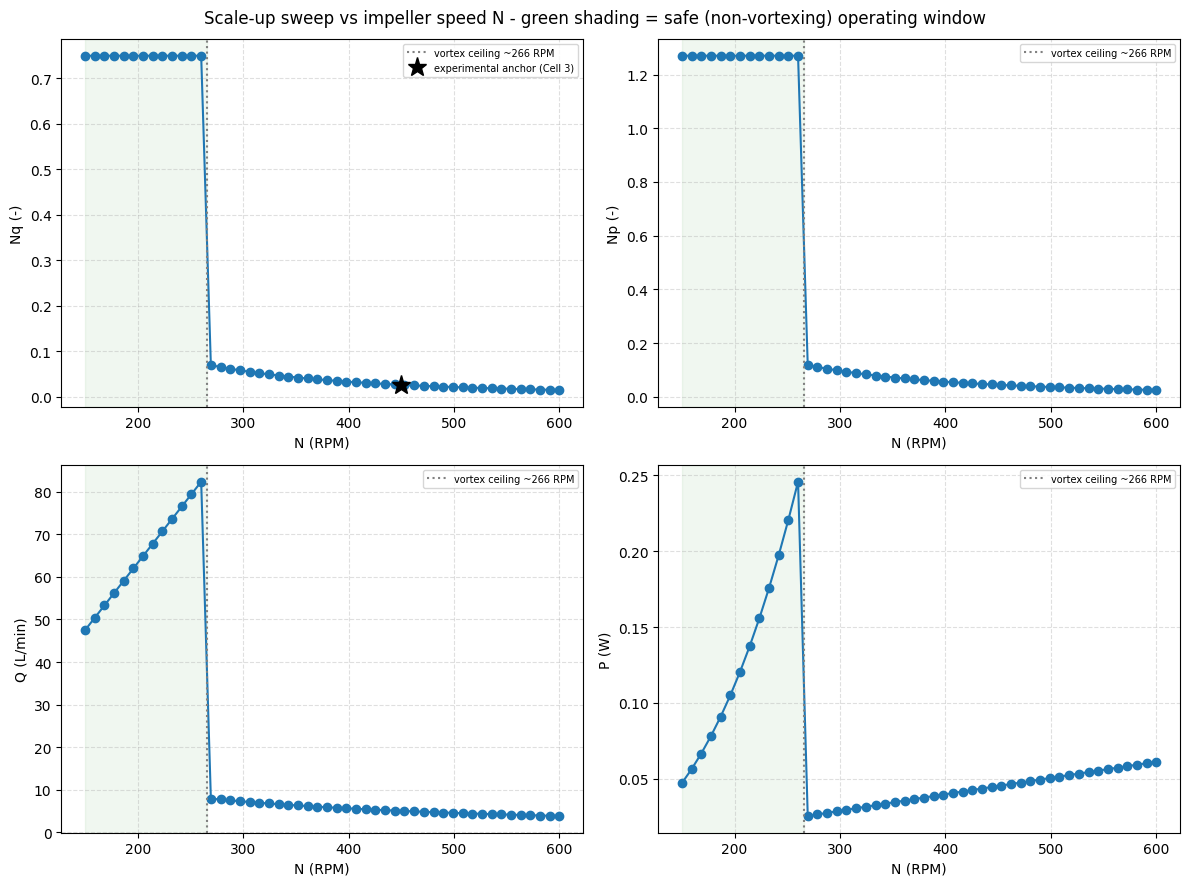

,RPM,N_rps,Re_i,Fr_i,Nq,Np,Q_L_min,P_W
0,150.0000,2.5000,15800.5618,0.0478,0.7500,1.2700,47.4609,0.0471
1,159.1837,2.6531,16767.9431,0.0538,0.7500,1.2700,50.3667,0.0563
2,168.3673,2.8061,17735.3245,0.0602,0.7500,1.2700,53.2725,0.0666
3,177.5510,2.9592,18702.7058,0.0669,0.7500,1.2700,56.1783,0.0781
4,186.7347,3.1122,19670.0871,0.0741,0.7500,1.2700,59.0840,0.0909
5,195.9184,3.2653,20637.4685,0.0815,0.7500,1.2700,61.9898,0.1049
6,205.1020,3.4184,21604.8498,0.0893,0.7500,1.2700,64.8956,0.1204
7,214.2857,3.5714,22572.2311,0.0975,0.7500,1.2700,67.8013,0.1373
8,223.4694,3.7245,23539.6125,0.1061,0.7500,1.2700,70.7071,0.1557
9,232.6531,3.8776,24506.9938,0.1149,0.7500,1.2700,73.6129,0.1757


In [8]:
# ==============================================================================
# CELL 6b: Nq(N) / Np(N) / Q(N) / P(N) - SCALING FRAMEWORK + OPTIMAL RPM
# ==============================================================================
# Toggle N_query_rpm below and re-run this cell: every dependent parameter
# (Nq, Np, Q, P) recalculates automatically from the functions defined here.
# No gas-sparging / kLa framework is included - this vessel is unbaffled and
# has no sparger; see the markdown above for why that framework was removed.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Re_turbulent_onset = 10000.0   # Welty Fig. 30.7 turbulent-plateau onset
Re_laminar_end = 10.0          # Welty Fig. 30.7 laminar closed-form upper bound
Kp_laminar = 70.0              # Po*Re_i ~= Kp in the laminar limit (Rushton-type turbines,
                                # order-of-magnitude literature constant - illustrative only,
                                # since Re_i never drops this low in this system's practical range)
Np_plateau_lit = 1.27          # literature turbulent Np for a 4-blade 45 deg PBT (Bates, Fondy &
                                # Corpstein-type impeller tables; Welty Fig. 30.7 only tabulates
                                # flat-blade turbine/paddle/marine-propeller curves explicitly,
                                # not PBT, so this is a labeled external literature value)

def Re_i_of_N(N_rps_query, D=D_impeller_m, rho=rho_kg_m3, mu=mu_Pa_s):
    return rho * N_rps_query * D ** 2 / mu

def Fr_i_of_N(N_rps_query, D=D_impeller_m, g=g):
    return N_rps_query ** 2 * D / g

def _regime_scaled(Re_i_query, plateau_value):
    """Re_i-regime scaling shared by Np and Nq (Welty Fig. 30.7 shape): ~1/Re_i in the
    laminar limit, a flat plateau in the turbulent limit, and a log-log interpolation
    (visualization only, NOT a validated correlation - Welty gives no closed form here)
    in between."""
    if Re_i_query <= Re_laminar_end:
        return Kp_laminar / Re_i_query
    if Re_i_query >= Re_turbulent_onset:
        return plateau_value
    val_lo = Kp_laminar / Re_laminar_end
    frac = (np.log10(Re_i_query) - np.log10(Re_laminar_end)) / \
           (np.log10(Re_turbulent_onset) - np.log10(Re_laminar_end))
    return 10 ** (np.log10(val_lo) + frac * (np.log10(plateau_value) - np.log10(val_lo)))

def Nq_of_N(N_rps_query):
    """Flow number at impeller speed N (rev/s): Reynolds regime, then unbaffled
    vortex (Froude) correction anchored to the Cell 3 titration fit."""
    Re_i_q = Re_i_of_N(N_rps_query)
    Fr_i_q = Fr_i_of_N(N_rps_query)
    base = _regime_scaled(Re_i_q, Nq_plateau_lit)
    if Re_i_q >= Re_turbulent_onset and Fr_i_q > Fr_crit_unbaffled:
        return base / (1.0 + k_vortex * Fr_i_q)
    return base

def Np_of_N(N_rps_query):
    """Power number at impeller speed N (rev/s) - same regime logic as Nq(N);
    see the Np caveat in the markdown above (vortex knock-down inferred, not
    independently power-measured)."""
    Re_i_q = Re_i_of_N(N_rps_query)
    Fr_i_q = Fr_i_of_N(N_rps_query)
    base = _regime_scaled(Re_i_q, Np_plateau_lit)
    if Re_i_q >= Re_turbulent_onset and Fr_i_q > Fr_crit_unbaffled:
        return base / (1.0 + k_vortex * Fr_i_q)
    return base

def Q_of_N(N_rps_query, D=D_impeller_m):
    """Pumping rate Q (m^3/s) at impeller speed N (rev/s)."""
    return Nq_of_N(N_rps_query) * N_rps_query * D ** 3

def P_of_N(N_rps_query, D=D_impeller_m, rho=rho_kg_m3):
    """Power draw P (W), Welty eq. (30-35): Po = P*gc / (rho * N^3 * D^5), gc=1 in SI."""
    return Np_of_N(N_rps_query) * rho * N_rps_query ** 3 * D ** 5

# ---------------------------------------------------------------------------
# TOGGLE N HERE - everything below recalculates automatically
# ---------------------------------------------------------------------------
N_query_rpm = 450.0
N_query_rps = N_query_rpm / 60.0
Nq_q = Nq_of_N(N_query_rps)
Np_q = Np_of_N(N_query_rps)
Q_q_m3s = Q_of_N(N_query_rps)
P_q = P_of_N(N_query_rps)

print(f"===== Recalculated at N = {N_query_rpm:.0f} RPM ({N_query_rps:.3f} rev/s) =====")
print(f" Re_i               : {Re_i_of_N(N_query_rps):,.0f}")
print(f" Fr_i               : {Fr_i_of_N(N_query_rps):.4f}")
print(f" Nq                 : {Nq_q:.4f}")
print(f" Np                 : {Np_q:.4f}")
print(f" Q                  : {Q_q_m3s*1000*60:.4f} L/min")
print(f" P                  : {P_q:.4f} W")

# ---------------------------------------------------------------------------
# Sweep across the practical RPM window to show Nq, Np, Q, P vs N
# ---------------------------------------------------------------------------
rpm_sweep = np.linspace(150, 600, 50)
N_rps_sweep_arr = rpm_sweep / 60.0
sweep_df = pd.DataFrame({
    'RPM': rpm_sweep,
    'N_rps': N_rps_sweep_arr,
    'Re_i': [Re_i_of_N(n) for n in N_rps_sweep_arr],
    'Fr_i': [Fr_i_of_N(n) for n in N_rps_sweep_arr],
    'Nq': [Nq_of_N(n) for n in N_rps_sweep_arr],
    'Np': [Np_of_N(n) for n in N_rps_sweep_arr],
    'Q_L_min': [Q_of_N(n) * 1000 * 60 for n in N_rps_sweep_arr],
    'P_W': [P_of_N(n) for n in N_rps_sweep_arr],
})

# ---------------------------------------------------------------------------
# OPTIMAL RPM: highest N (within the sweep) that keeps Fr_i at/below the
# unbaffled vortex ceiling - i.e. the last point on the productive branch of
# Q(N) before the vortex-induced collapse.
# ---------------------------------------------------------------------------
safe_mask = sweep_df['Fr_i'] <= Fr_crit_unbaffled
rpm_ceiling_analytical = N_max_unbaffled_rps * 60.0  # exact Fr_crit=0.15 boundary, from Cell 1b

print("\n========================= OPTIMAL RPM (MAX Q, NO VORTEXING) =========================")
if safe_mask.any():
    idx_opt = sweep_df.loc[safe_mask, 'Q_L_min'].idxmax()
    optimal_row = sweep_df.loc[idx_opt]
    print(f" Analytical vortex ceiling (Fr_i = {Fr_crit_unbaffled}): {rpm_ceiling_analytical:.1f} RPM")
    print(f" Best sampled point at/below ceiling            : {optimal_row['RPM']:.1f} RPM, "
          f"Q = {optimal_row['Q_L_min']:.2f} L/min (Fr_i = {optimal_row['Fr_i']:.4f})")
    if safe_mask.all() is False:
        first_unsafe = sweep_df.loc[~safe_mask, 'Q_L_min'].iloc[0]
        print(f" Q just past the ceiling collapses to           : {first_unsafe:.2f} L/min "
              f"({(1 - first_unsafe/optimal_row['Q_L_min'])*100:.0f}% drop)")
    print(f"\n RECOMMENDATION: operate at approximately {rpm_ceiling_analytical:.0f} RPM "
          f"({rpm_ceiling_analytical/60:.2f} rev/s) - the highest speed that keeps Fr_i at/below "
          f"{Fr_crit_unbaffled} for this D = {D_impeller_m*100:.1f} cm impeller. This maximizes Q "
          f"while staying out of the vortex-collapsed regime.")
else:
    print(" No RPM in the sweep window stays below the vortex ceiling - narrow the sweep range.")
print("=======================================================================================")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()
panels = [('Nq', 'Nq (-)'), ('Np', 'Np (-)'), ('Q_L_min', 'Q (L/min)'), ('P_W', 'P (W)')]
for ax, (col, ylabel) in zip(axes, panels):
    ax.plot(sweep_df['RPM'], sweep_df[col], 'o-', color='#1f77b4')
    ax.axvline(rpm_ceiling_analytical, color='gray', linestyle=':',
               label=f'vortex ceiling ~{rpm_ceiling_analytical:.0f} RPM')
    ax.axvspan(sweep_df['RPM'].min(), rpm_ceiling_analytical, color='green', alpha=0.06)
    ax.set_xlabel('N (RPM)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)
axes[0].plot([450], [Nq], '*', color='black', markersize=14, label='experimental anchor (Cell 3)')
axes[0].legend(fontsize=7)
plt.suptitle('Scale-up sweep vs impeller speed N - green shading = safe (non-vortexing) operating window')
plt.tight_layout()
plt.show()

sweep_df.round(4)


Preset scenario: Nq = 0.044, N = 160 RPM (2.6667 rev/s), t_max = 10 min (600 s)
Derived circulation flow Q = 2.9700 L/min  (from Q = Nq * N * D^3)


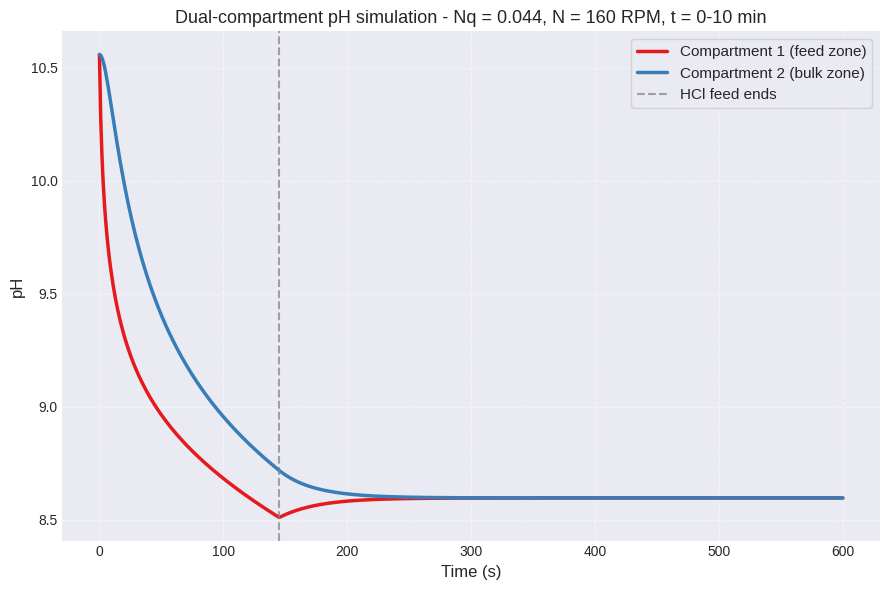


Final Compartment 1 (feed zone) pH @ t = 10 min : 8.5972
Final Compartment 2 (bulk zone)  pH @ t = 10 min : 8.5972
Max inter-compartment pH gap over the run                : 0.7392


In [9]:
# ==============================================================================
# CELL 7: PRESET SCENARIO - Nq = 0.044, N = 160 RPM, DUAL-COMPARTMENT pH TRACE
# ==============================================================================
Nq_preset = 0.044
RPM_preset = 160.0
N_rps_preset = RPM_preset / 60.0     # 160 RPM -> rev/s
t_max_min_preset = 10.0              # 10 minutes = 600 seconds

Q_preset_m3_s = Nq_preset * N_rps_preset * D_impeller_m ** 3
Q_preset_L_min = Q_preset_m3_s * 1000.0 * 60.0
print(f"Preset scenario: Nq = {Nq_preset}, N = {RPM_preset:.0f} RPM ({N_rps_preset:.4f} rev/s), "
      f"t_max = {t_max_min_preset:.0f} min ({t_max_min_preset*60:.0f} s)")
print(f"Derived circulation flow Q = {Q_preset_L_min:.4f} L/min  (from Q = Nq * N * D^3)")


def simulate_ph_dual_compartment(Q_L_min, t_eval_min, pH0):
    """Same 2-zone mass-action model as Cell 3's simulate_ph, but returns BOTH
    Compartment 1 (Zone 1, feed zone) and Compartment 2 (Zone Bulk) pH(t) traces
    instead of collapsing to the Zone-1-only probe signal."""
    ratio0 = 10 ** (pH0 - pKa_tris)
    frac_TrisH_0 = 1.0 / (1.0 + ratio0)
    n_Tris_1_0 = (1 - frac_TrisH_0) * C_Tris_stock_M * V1_initial_L
    n_TrisH_1_0 = frac_TrisH_0 * C_Tris_stock_M * V1_initial_L
    n_Tris_B_0 = (1 - frac_TrisH_0) * C_Tris_stock_M * V_bulk_L
    n_TrisH_B_0 = frac_TrisH_0 * C_Tris_stock_M * V_bulk_L
    y0 = [n_Tris_1_0, n_TrisH_1_0, n_Tris_B_0, n_TrisH_B_0]

    def ode(t_min, y):
        n_Tris_1, n_TrisH_1, n_Tris_B, n_TrisH_B = np.maximum(y, 0.0)
        V1 = V1_of_t(t_min)
        C_Tris_1, C_TrisH_1 = n_Tris_1 / V1, n_TrisH_1 / V1
        C_Tris_B, C_TrisH_B = n_Tris_B / V_bulk_L, n_TrisH_B / V_bulk_L
        exch_Tris = Q_L_min * (C_Tris_1 - C_Tris_B)
        exch_TrisH = Q_L_min * (C_TrisH_1 - C_TrisH_B)
        h_feed = feed_rate_mol_min(t_min)
        dn_Tris_1 = -exch_Tris - h_feed
        dn_TrisH_1 = -exch_TrisH + h_feed
        dn_Tris_B = +exch_Tris
        dn_TrisH_B = +exch_TrisH
        return [dn_Tris_1, dn_TrisH_1, dn_Tris_B, dn_TrisH_B]

    t_end = t_eval_min[-1]
    if t_end <= t_feed_end_min:
        sol = solve_ivp(ode, (0, t_end), y0, t_eval=t_eval_min, method='BDF', rtol=1e-7, atol=1e-10)
        Y = sol.y
    else:
        mask1 = t_eval_min <= t_feed_end_min
        t1 = np.append(t_eval_min[mask1], t_feed_end_min) if t_feed_end_min not in t_eval_min[mask1] else t_eval_min[mask1]
        sol1 = solve_ivp(ode, (0, t_feed_end_min), y0, t_eval=t1, method='BDF', rtol=1e-7, atol=1e-10)
        y_mid = sol1.y[:, -1]
        t2 = t_eval_min[~mask1]
        sol2 = solve_ivp(ode, (t_feed_end_min, t_end), y_mid, t_eval=t2, method='BDF', rtol=1e-7, atol=1e-10)
        Y = np.hstack([sol1.y[:, :len(t_eval_min[mask1])], sol2.y])

    n_Tris_1, n_TrisH_1, n_Tris_B, n_TrisH_B = Y[0], Y[1], Y[2], Y[3]
    V1_series = np.array([V1_of_t(tm) for tm in t_eval_min])
    C_Tris_1 = np.maximum(n_Tris_1, 1e-12) / V1_series
    C_TrisH_1 = np.maximum(n_TrisH_1, 1e-12) / V1_series
    C_Tris_B = np.maximum(n_Tris_B, 1e-12) / V_bulk_L
    C_TrisH_B = np.maximum(n_TrisH_B, 1e-12) / V_bulk_L
    pH_1 = pKa_tris + np.log10(C_Tris_1 / C_TrisH_1)
    pH_B = pKa_tris + np.log10(C_Tris_B / C_TrisH_B)
    return pH_1, pH_B


t_eval_min_preset = np.linspace(0.0, t_max_min_preset, 601)   # 601 pts -> 1-second resolution over 600 s
t_eval_sec_preset = t_eval_min_preset * 60.0
pH0_preset = pH_measured[0]

pH_1_preset, pH_B_preset = simulate_ph_dual_compartment(Q_preset_L_min, t_eval_min_preset, pH0_preset)

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(t_eval_sec_preset, pH_1_preset, '-', color='#e41a1c', linewidth=2.5, label='Compartment 1 (feed zone)')
ax.plot(t_eval_sec_preset, pH_B_preset, '-', color='#377eb8', linewidth=2.5, label='Compartment 2 (bulk zone)')
ax.axvline(x=t_feed_end_min * 60, color='gray', linestyle='--', alpha=0.7, label='HCl feed ends')
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('pH', fontsize=12)
ax.set_title(f'Dual-compartment pH simulation - Nq = {Nq_preset}, N = {RPM_preset:.0f} RPM, '
             f't = 0-{t_max_min_preset:.0f} min', fontsize=13)
ax.legend(fontsize=11, loc='best', frameon=True)
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

print(f"\nFinal Compartment 1 (feed zone) pH @ t = {t_max_min_preset:.0f} min : {pH_1_preset[-1]:.4f}")
print(f"Final Compartment 2 (bulk zone)  pH @ t = {t_max_min_preset:.0f} min : {pH_B_preset[-1]:.4f}")
print(f"Max inter-compartment pH gap over the run                : {np.max(np.abs(pH_1_preset - pH_B_preset)):.4f}")
